# Fase 2 — Comprensión de los Datos
## Sección 03: Distribución de Precios

**Notebook:** `notebooks/03_EDA_distribucion_precios.ipynb`
**Responsable:** Sofía | **Apoyo:** Steve
**Objetivo:** Analizar la distribución de precios de vivienda en los datasets del Grupo A, identificar outliers y documentar hallazgos.

## Configuración inicial

In [1]:
from config import *

---


### Cargar datasets del Grupo A y detectar columna precio

In [2]:
A_FILES = [
    ("A1", "A1_colombia_housing_properties.csv", "price"),
    ("A2", "A2_fincaraiz_colombia.csv", "Precio"),
    ("A3", "A3_colombia_house_prediction.csv", "valor"),
    ("A4", "A4_real_estate_bogota.csv", "Valor"),
    ("A5", "A5_medellin_properties_2023.csv", "price"),
    ("A6", "A6_real_estate_bogota_2023.csv", "precio"),
    ("A7", "A7_fincaraiz_villavicencio_scraping.csv", "precio_cop"),
    ("A8", "A8_carac_pre_viv_nueva.csv", "precios"),
]
prices = {}
for fid, fname, pcol in A_FILES:
    df = pd.read_csv(os.path.join(RAW, fname), encoding="utf-8-sig", low_memory=False)
    prices[fid] = {"df": df, "pcol": pcol}
    size_mb = os.path.getsize(os.path.join(RAW, fname)) / 1e6
    print(f"[OK] {fid} {fname:45s} {df.shape[0]:>8,} filas  {size_mb:>7.1f} MB  precio: {pcol}")


[OK] A1 A1_colombia_housing_properties.csv             997,623 filas    581.8 MB  precio: price
[OK] A2 A2_fincaraiz_colombia.csv                      142,833 filas     52.5 MB  precio: Precio
[OK] A3 A3_colombia_house_prediction.csv               145,552 filas     26.8 MB  precio: valor
[OK] A4 A4_real_estate_bogota.csv                        9,520 filas      0.9 MB  precio: Valor
[OK] A5 A5_medellin_properties_2023.csv                  9,999 filas      0.9 MB  precio: price
[OK] A6 A6_real_estate_bogota_2023.csv                     585 filas      0.5 MB  precio: precio
[OK] A7 A7_fincaraiz_villavicencio_scraping.csv          1,048 filas      0.3 MB  precio: precio_cop
[OK] A8 A8_carac_pre_viv_nueva.csv                          32 filas      0.0 MB  precio: precios


### Estadísticas descriptivas de precio — A1 (Properati)

In [3]:
p = prices["A1"]["df"]["price"].copy()
p_valid = p.dropna()
p_clean = p_valid[p_valid > 0]
stats = {
    "Registros totales": f"{len(p):,}",
    "Precios nulos": f"{p.isnull().sum():,}",
    "% Nulos": f"{p.isnull().mean()*100:.2f}%",
    "Precios <= 0": f"{int((p_valid <= 0).sum()):,}",
    "Válidos (positivos)": f"{len(p_clean):,}",
    "Mínimo": f"${p_clean.min():,.0f}",
    "P1": f"${p_clean.quantile(0.01):,.0f}",
    "Q1": f"${p_clean.quantile(0.25):,.0f}",
    "Mediana": f"${p_clean.median():,.0f}",
    "Media": f"${p_clean.mean():,.0f}",
    "Q3": f"${p_clean.quantile(0.75):,.0f}",
    "P99": f"${p_clean.quantile(0.99):,.0f}",
    "Máximo": f"${p_clean.max():,.0f}",
    "Std Dev": f"${p_clean.std():,.0f}",
}
df_stats = pd.DataFrame.from_dict(
    stats,
    orient="index",
    columns=["Valor"]
)
print("===== RESUMEN ESTADÍSTICO DE PRECIOS - DATASET A1 =====\n")
display(df_stats)

===== RESUMEN ESTADÍSTICO DE PRECIOS - DATASET A1 =====



,Valor
Registros totales,"997,623"
Precios nulos,0
% Nulos,0.00%
Precios <= 0,0
Válidos (positivos),"997,623"
Mínimo,"$100,000"
P1,"$502,110"
Q1,"$1,800,000"
Mediana,"$152,000,000"
Media,"$390,570,515"


### Estadísticas descriptivas — todos los datasets

In [13]:
all_stats = []
for fid, d in prices.items():
    pcol = d["pcol"]
    pvals = d["df"][pcol].dropna()
    pvals = pvals[pvals > 0]

    if len(pvals) == 0:
        continue

    all_stats.append({
        "Dataset": fid,
        "N válidos": len(pvals),
        "Min": pvals.min(),
        "P1": pvals.quantile(0.01),
        "Q1": pvals.quantile(0.25),
        "Mediana": pvals.median(),
        "Media": pvals.mean(),
        "Q3": pvals.quantile(0.75),
        "P99": pvals.quantile(0.99),
        "Max": pvals.max(),
        "Std": pvals.std(),
    })

df_stats = pd.DataFrame(all_stats)

df_stats["N válidos"] = df_stats["N válidos"].map(lambda x: f"{x:,}")

for col in ["Min", "P1", "Q1", "Mediana", "Media", "Q3", "P99", "Max", "Std"]:
    df_stats[col] = df_stats[col].map(lambda x: f"${x:,.0f}")

display(df_stats)

path_stats = os.path.join(PROC, "estadisticas_precio.csv")
df_stats.to_csv(path_stats, index=False)

print(f"\nTabla guardada en: {path_stats}")

,Dataset,N válidos,Min,P1,Q1,Mediana,Media,Q3,P99,Max,Std
0,A1,"997,623","$100,000","$502,110","$1,800,000","$152,000,000","$390,570,515","$395,000,000","$3,900,000,000","$50,000,000,000","$1,182,485,201"
1,A2,"142,833","$126,500","$115,000,000","$265,000,000","$450,000,000","$682,068,401","$790,000,000","$3,800,000,000","$11,000,000,000","$742,755,559"
2,A3,"145,550",$450,"$115,000,000","$320,000,000","$490,000,000","$1,401,171,485","$820,000,000","$3,500,000,000","$4,100,000,000,000","$28,294,536,295"
3,A4,"9,520","$60,000,000","$115,000,000","$250,000,000","$409,182,500","$602,062,354","$680,000,000","$3,500,000,000","$16,000,000,000","$704,602,062"
4,A5,"9,999","$1,600,000","$126,771,802","$300,000,000","$420,000,000","$1,451,617,270","$665,000,000","$4,100,000,000","$3,100,000,000,000","$37,257,501,856"
5,A6,585,"$85,000,000","$97,664,000","$152,000,000","$218,421,053","$260,780,218","$352,000,000","$663,712,000","$1,530,000,000","$148,218,269"
6,A7,"1,048","$100,000","$473,500","$140,000,000","$270,000,000","$583,787,519","$480,000,000","$4,802,846,280","$35,000,000,000","$1,935,773,390"
7,A8,32,$2,$2,$5,$6,$7,$9,$16,$16,$3



Tabla guardada en: ..\data\processed\estadisticas_precio.csv


### Distribución de precio — histograma escala original

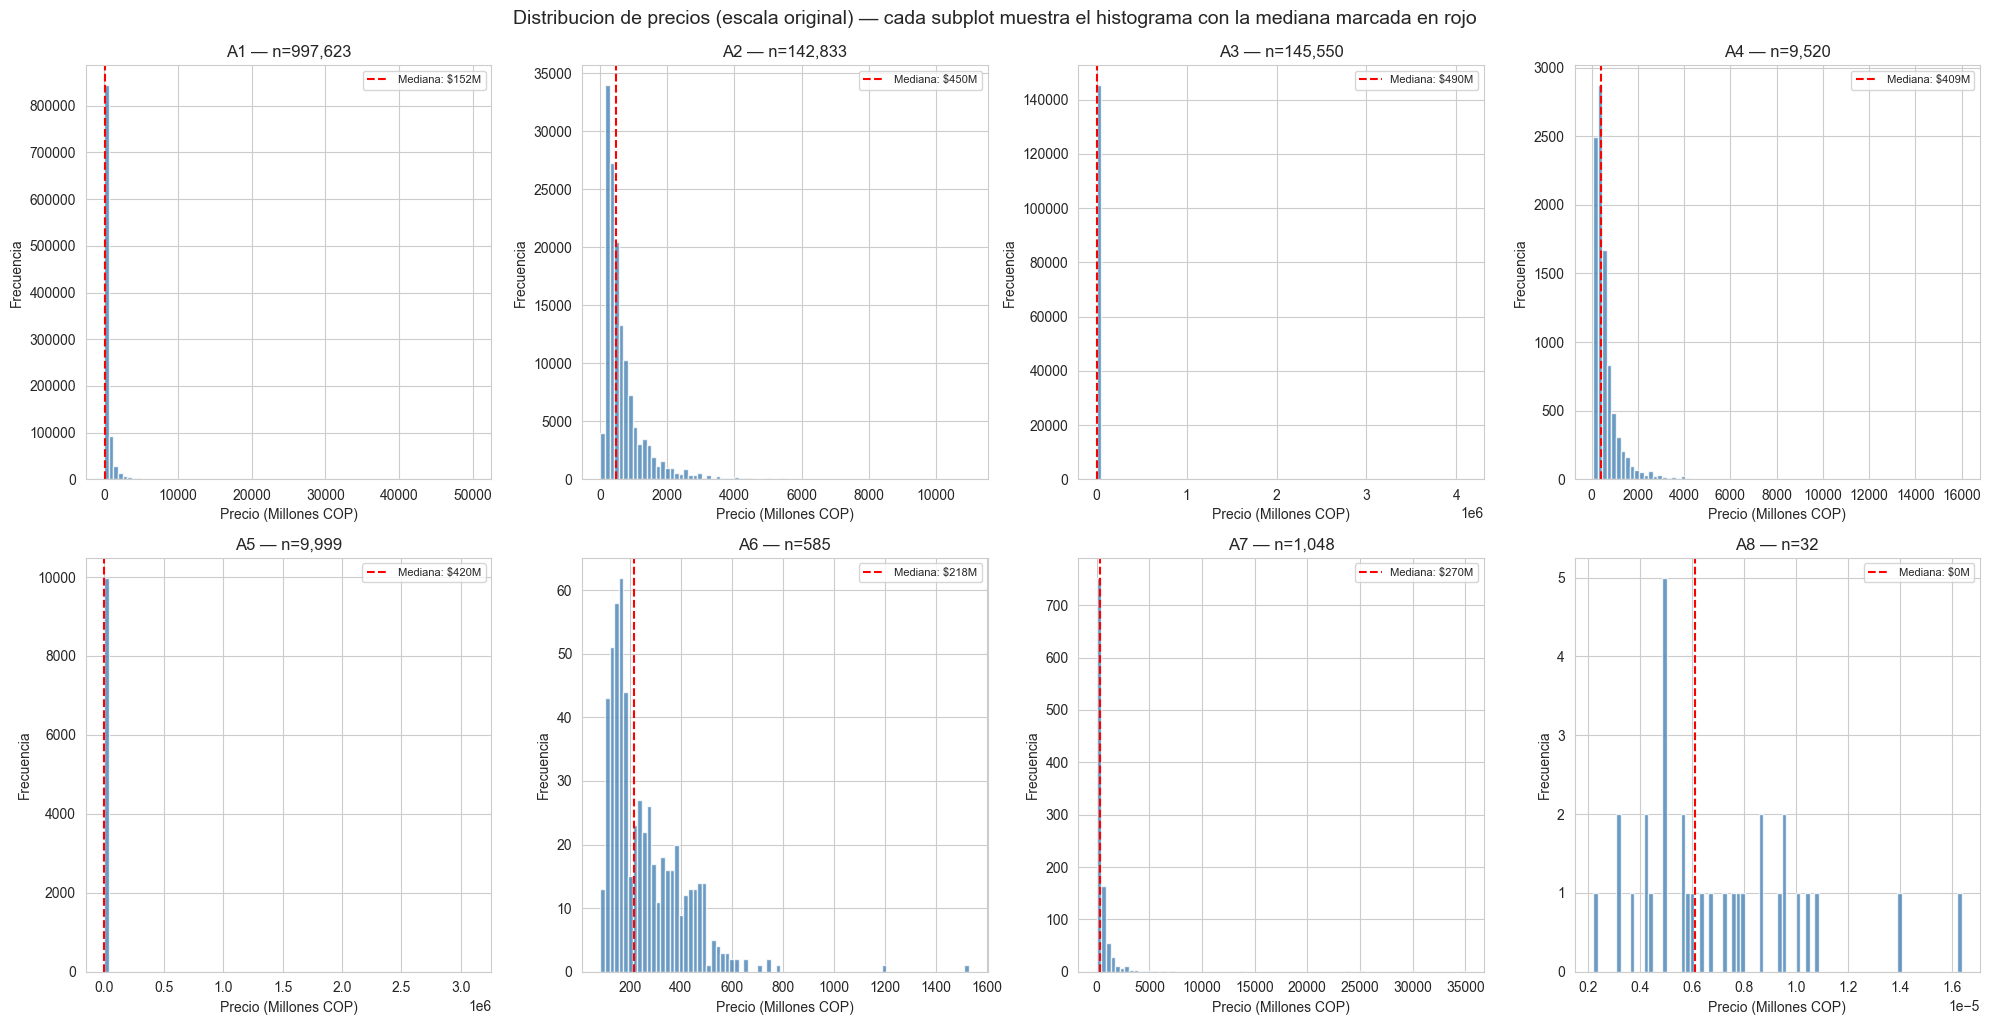

Gráfico guardado en: ..\docs\figures\hist_precio_original.png


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (fid, d) in enumerate(prices.items()):
    pvals = d["df"][d["pcol"]].dropna()
    pvals = pvals[pvals > 0]

    axes[i].hist(
        pvals / 1e6,
        bins=80,
        color="steelblue",
        edgecolor="white",
        alpha=0.8
    )

    axes[i].axvline(
        pvals.median() / 1e6,
        color="red",
        ls="--",
        lw=1.5,
        label=f"Mediana: ${pvals.median()/1e6:.0f}M"
    )

    axes[i].set_title(f"{fid} — n={len(pvals):,}")
    axes[i].set_xlabel("Precio (Millones COP)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

plt.tight_layout()

fig.suptitle(
    "Distribucion de precios (escala original) — cada subplot muestra el histograma con la mediana marcada en rojo",
    fontsize=14,
    y=1.02
)

path_fig = os.path.join(FIGS, "hist_precio_original.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Gráfico guardado en: {path_fig}")

**Conclusion histograma original:**
- A1 (Properati) muestra distribucion bimodal con picos cerca de $1M y $150M — sugiere mezcla de terrenos y viviendas.
- A2, A3, A4, A5 tienen cola larga a la derecha con mediana ~$300-500M.
- A8 (vivienda nueva) tiene precios < $16 — claramente en otra unidad (millones o faltan ceros).
- A6 (Bogota 2023) es el dataset mas homogeneo: rango estrecho, sin cola larga.


### Distribución de precio — histograma escala log

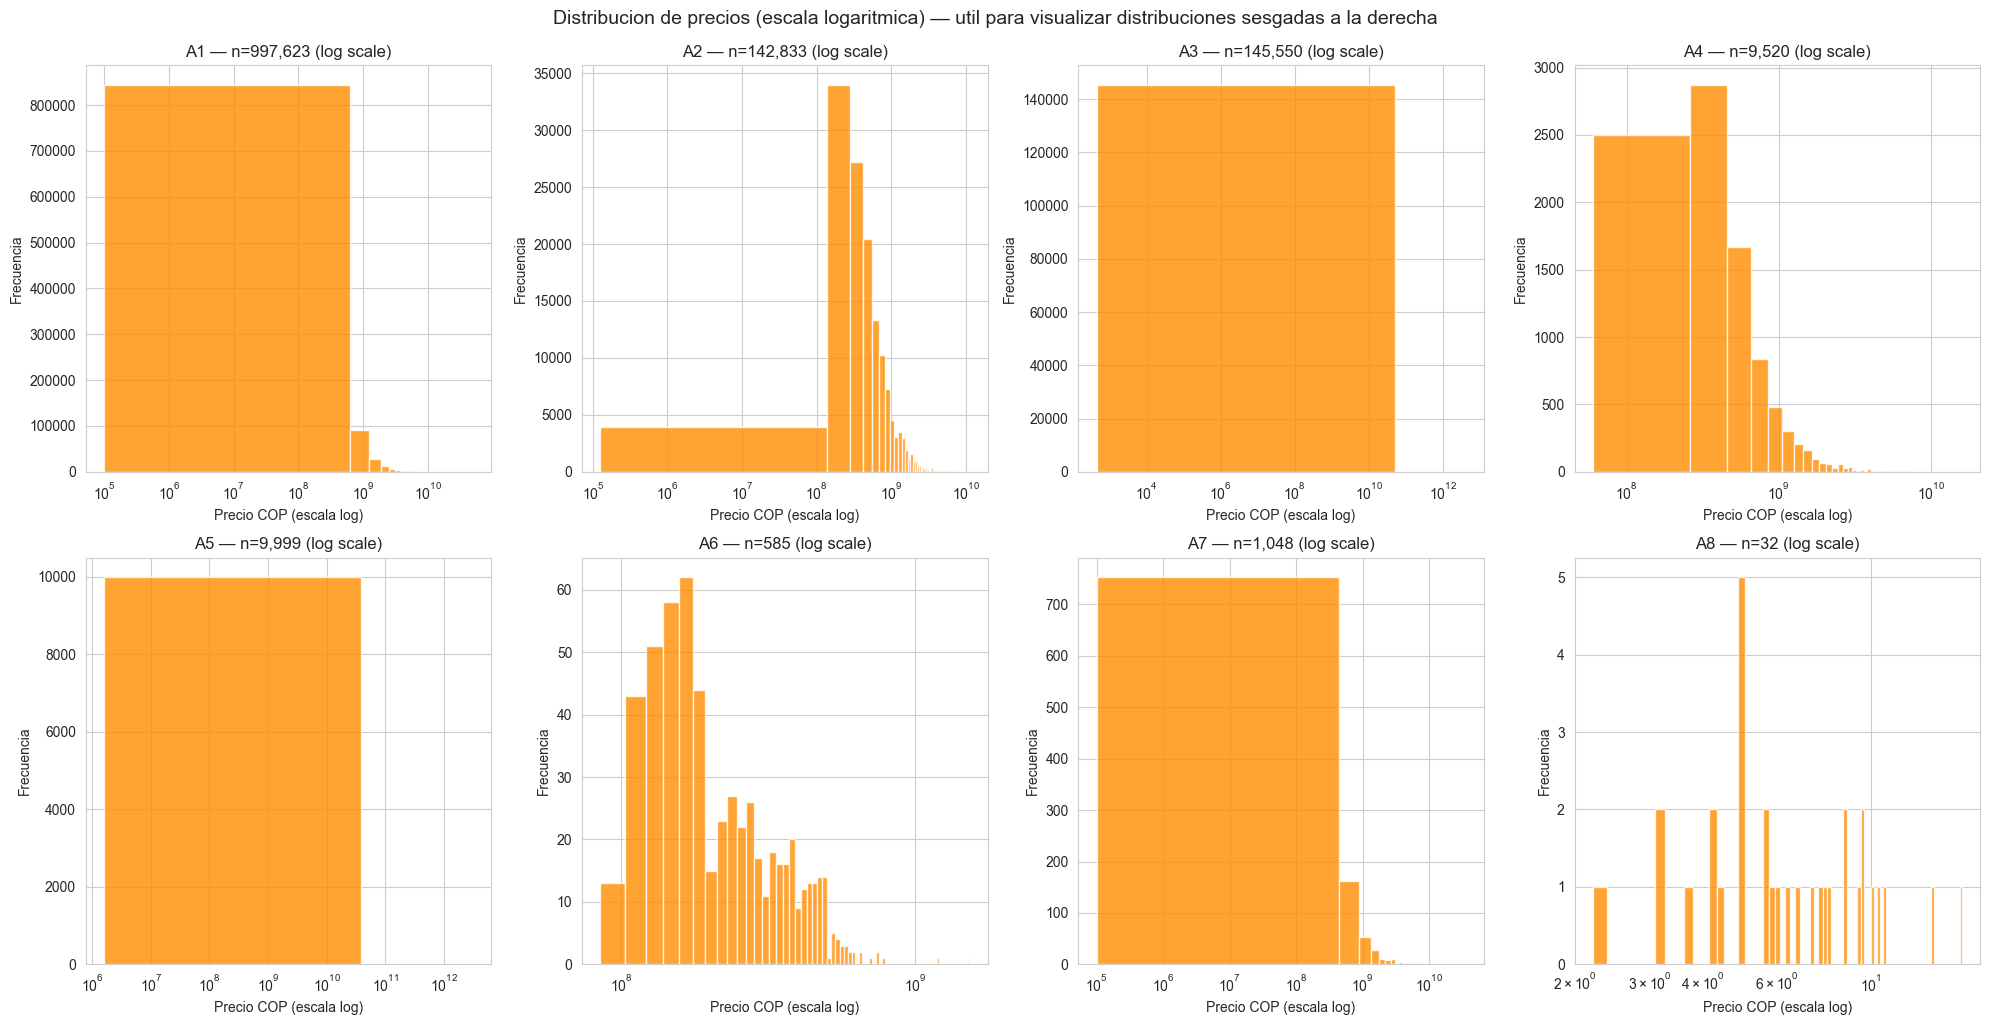

Gráfico guardado en: ..\docs\figures\hist_precio_log.png


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (fid, d) in enumerate(prices.items()):
    pvals = d["df"][d["pcol"]].dropna()
    pvals = pvals[pvals > 0]

    axes[i].hist(
        pvals,
        bins=80,
        color="darkorange",
        edgecolor="white",
        alpha=0.8
    )

    axes[i].set_xscale("log")
    axes[i].set_title(f"{fid} — n={len(pvals):,} (log scale)")
    axes[i].set_xlabel("Precio COP (escala log)")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()

fig.suptitle(
    "Distribucion de precios (escala logaritmica) — util para visualizar distribuciones sesgadas a la derecha",
    fontsize=14,
    y=1.02
)

path_fig = os.path.join(FIGS, "hist_precio_log.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Gráfico guardado en: {path_fig}")

**Conclusion histograma log:**
- Con escala logaritmica, A1, A2, A7 muestran distribucion aproximadamente normal — indica que log(price) se ajusta a modelos lineales.
- A3 y A5 tienen picos artificiales en ~$500M y ~$4B — posiblemente precios redondeados o valores predichos por modelo.
- A8 y A6 tienen pocas observaciones; las barras son poco informativas.


### Boxplot de precio por dataset

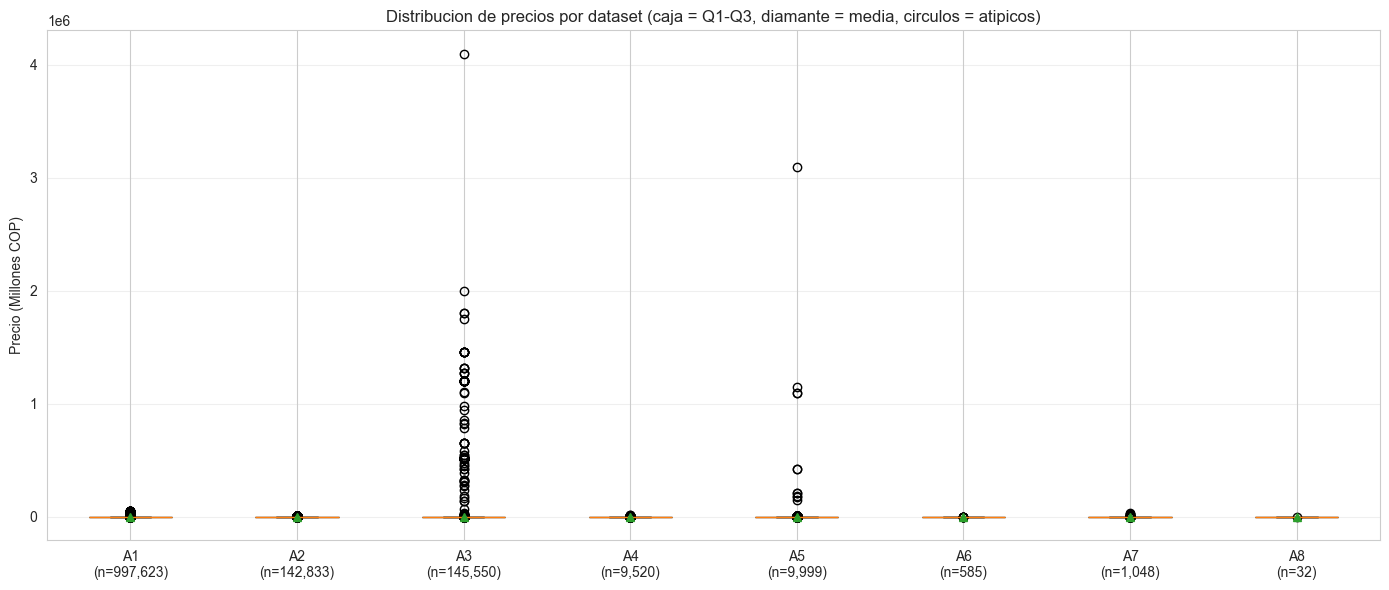

Boxplot guardado en: ..\docs\figures\boxplot_precio.png


In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

bp_data = []
bp_labels = []

for fid, d in prices.items():
    pvals = d["df"][d["pcol"]].dropna()
    pvals = pvals[pvals > 0] / 1e6

    bp_data.append(pvals)
    bp_labels.append(f"{fid}\n(n={len(pvals):,})")

bp = ax.boxplot(
    bp_data,
    labels=bp_labels,
    patch_artist=True,
    showmeans=True
)

for patch, color in zip(bp["boxes"], sns.color_palette("Set2", len(bp_data))):
    patch.set_facecolor(color)

ax.set_ylabel("Precio (Millones COP)")
ax.set_title(
    "Distribucion de precios por dataset (caja = Q1-Q3, diamante = media, circulos = atipicos)"
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

path_fig = os.path.join(FIGS, "boxplot_precio.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Boxplot guardado en: {path_fig}")

**Conclusion boxplot:**
- A2 (FincaRaiz) tiene la mediana mas alta ($450M) y una distribucion compacta — refleja el mercado formal.
- A1 (Properati) tiene la mediana mas baja ($152M) y la mayor dispersion — incluye desde terrenos baratos hasta propiedades de lujo.
- A3 y A5 presentan outliers extremos (hasta $4.1B) que sesgan fuertemente la media.
- A6 y A8 son datasets pequenos con rangos limitados.


---


### Identificar outliers bajos (< $10M COP) y altos (> $5,000M COP)

In [19]:
LIMITE_BAJO = 10_000_000
LIMITE_ALTO = 5_000_000_000

outliers_report = []

for fid, d in prices.items():
    pcol = d["pcol"]
    pvals = d["df"][pcol].dropna()
    pvals = pvals[pvals > 0]

    n_total = len(pvals)
    n_bajos = (pvals < LIMITE_BAJO).sum()
    n_altos = (pvals > LIMITE_ALTO).sum()

    outliers_report.append({
        "Dataset": fid,
        "N válidos": n_total,
        "Outliers bajos (<$10M)": n_bajos,
        "% Bajos": f"{n_bajos/n_total*100:.2f}%" if n_total else "N/A",
        "Outliers altos (>$5,000M)": n_altos,
        "% Altos": f"{n_altos/n_total*100:.2f}%" if n_total else "N/A",
        "% Outliers total": f"{(n_bajos+n_altos)/n_total*100:.2f}%" if n_total else "N/A",
    })

df_outliers = pd.DataFrame(outliers_report)

display(df_outliers)

path_outliers = os.path.join(PROC, "outliers_precio.csv")
df_outliers.to_csv(path_outliers, index=False)

print(f"\nReporte guardado en: {path_outliers}")

,Dataset,N válidos,Outliers bajos (<$10M),% Bajos,"Outliers altos (>$5,000M)",% Altos,% Outliers total
0,A1,997623,405452,40.64%,5982,0.60%,41.24%
1,A2,142833,94,0.07%,545,0.38%,0.45%
2,A3,145550,335,0.23%,404,0.28%,0.51%
3,A4,9520,0,0.00%,36,0.38%,0.38%
4,A5,9999,3,0.03%,51,0.51%,0.54%
5,A6,585,0,0.00%,0,0.00%,0.00%
6,A7,1048,143,13.65%,10,0.95%,14.60%
7,A8,32,32,100.00%,0,0.00%,100.00%



Reporte guardado en: ..\data\processed\outliers_precio.csv


**Conclusion outliers tabla:**
- A1 tiene 41.24% de outliers totales, dominado por outliers bajos (40.64% con precio < $10M) — posiblemente terrenos o cuotas.
- A7 (Villavicencio) tiene 13.65% de outliers bajos y 14.60% total.
- A8 tiene 100% de outliers bajos — todos los registros estan en $2-$16, unidad incorrecta.
- A2-A6 tienen < 1% de outliers totales — datos de precio relativamente limpios.


### Top 5 precios más bajos

In [9]:
print("===== TOP 5 PRECIOS MÁS BAJOS POR DATASET =====\n")
for fid, d in prices.items():
    pcol = d["pcol"]
    df = d["df"]
    pvals = df[pcol].dropna()
    pvals = pvals[pvals > 0]
    lowest = df.loc[pvals.nsmallest(5).index, [pcol] if pcol else []]
    print(f"{fid} — 5 precios más bajos:")
    for idx, row in lowest.iterrows():
        print(f"    ${row[pcol]:>12,.0f}")
    print()


===== TOP 5 PRECIOS MÁS BAJOS POR DATASET =====

A1 — 5 precios más bajos:
    $     100,000
    $     100,000
    $     100,000
    $     100,000
    $     100,000

A2 — 5 precios más bajos:
    $     126,500
    $     136,000
    $     157,600
    $     185,000
    $     189,300

A3 — 5 precios más bajos:
    $         450
    $         780
    $     148,000
    $     175,000
    $     220,000

A4 — 5 precios más bajos:
    $  60,000,000
    $  74,300,000
    $  79,000,000
    $  82,000,000
    $  82,170,000

A5 — 5 precios más bajos:
    $   1,600,000
    $   1,700,000
    $   2,000,000
    $  43,000,000
    $  57,000,000

A6 — 5 precios más bajos:
    $  85,000,000
    $  90,000,000
    $  93,000,000
    $  95,000,000
    $  95,000,000

A7 — 5 precios más bajos:
    $     100,000
    $     300,000
    $     300,000
    $     300,000
    $     300,000

A8 — 5 precios más bajos:
    $           2
    $           3
    $           3
    $           4
    $           4



### Top 5 precios más altos

In [10]:
print("===== TOP 5 PRECIOS MÁS ALTOS POR DATASET =====\n")
for fid, d in prices.items():
    pcol = d["pcol"]
    df = d["df"]
    pvals = df[pcol].dropna()
    pvals = pvals[pvals > 0]
    highest = df.loc[pvals.nlargest(5).index, [pcol] if pcol else []]
    print(f"{fid} — 5 precios más altos:")
    for idx, row in highest.iterrows():
        print(f"    ${row[pcol]:>15,.0f}")
    print()


===== TOP 5 PRECIOS MÁS ALTOS POR DATASET =====

A1 — 5 precios más altos:
    $ 50,000,000,000
    $ 50,000,000,000
    $ 50,000,000,000
    $ 50,000,000,000
    $ 50,000,000,000

A2 — 5 precios más altos:
    $ 11,000,000,000
    $ 11,000,000,000
    $ 10,600,000,000
    $ 10,600,000,000
    $ 10,600,000,000

A3 — 5 precios más altos:
    $4,100,000,000,000
    $2,000,000,000,000
    $1,800,000,000,000
    $1,800,000,000,000
    $1,750,000,000,000

A4 — 5 precios más altos:
    $ 16,000,000,000
    $ 13,200,000,000
    $ 10,451,500,000
    $ 10,451,500,000
    $  9,200,000,000

A5 — 5 precios más altos:
    $3,100,000,000,000
    $1,150,000,000,000
    $1,100,000,000,000
    $1,100,000,000,000
    $425,000,000,000

A6 — 5 precios más altos:
    $  1,530,000,000
    $  1,200,000,000
    $    780,000,000
    $    745,000,000
    $    739,375,000

A7 — 5 precios más altos:
    $ 35,000,000,000
    $ 30,000,000,000
    $ 25,000,000,000
    $ 24,000,000,000
    $ 13,725,000,000

A8 — 5 pr

### Gráfica de outliers — dispersión por dataset

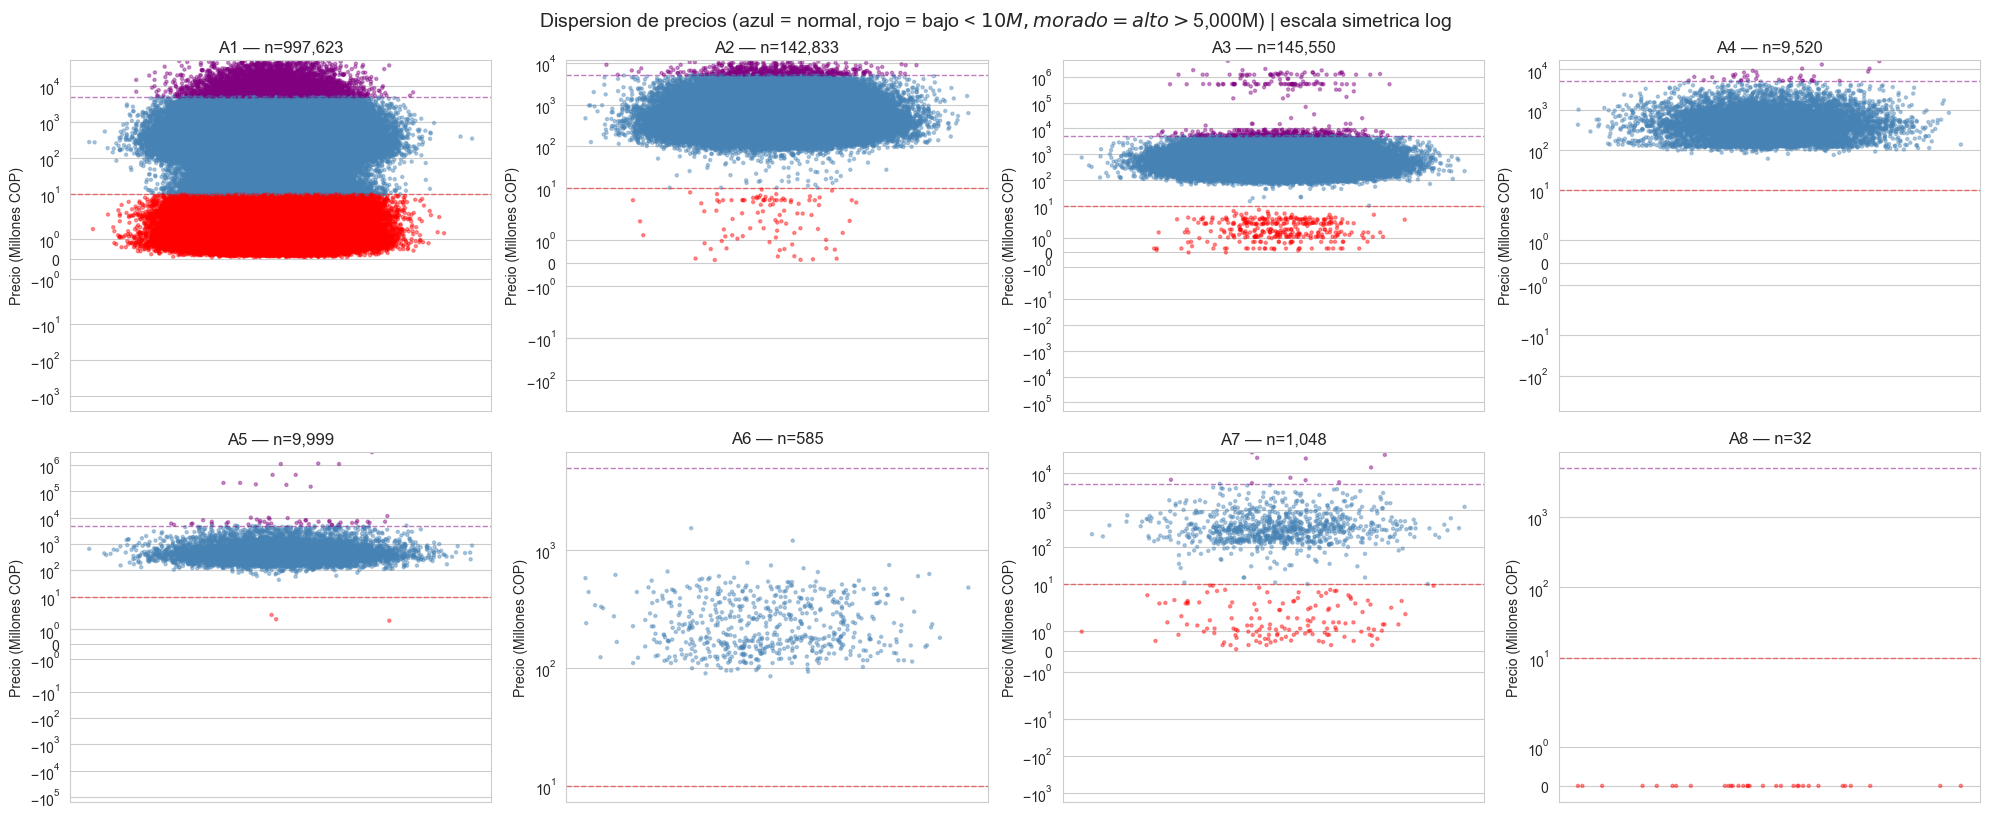

Gráfica de dispersión guardada en: ..\docs\figures\outliers_dispersion.png


In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, (fid, d) in enumerate(prices.items()):
    pvals = d["df"][d["pcol"]].dropna()
    pvals = pvals[pvals > 0]

    y = pvals / 1e6
    x = np.random.normal(0, 0.1, len(y))

    colors = np.where(
        y < 10,
        "red",
        np.where(y > 5000, "purple", "steelblue")
    )

    axes[i].scatter(x, y, c=colors, alpha=0.4, s=5)
    axes[i].axhline(10, color="red", ls="--", lw=1, alpha=0.5)
    axes[i].axhline(5000, color="purple", ls="--", lw=1, alpha=0.5)

    axes[i].set_yscale("symlog")
    axes[i].set_title(f"{fid} — n={len(y):,}")
    axes[i].set_ylabel("Precio (Millones COP)")
    axes[i].set_xlabel("")
    axes[i].set_xticks([])

plt.tight_layout()

fig.suptitle(
    "Dispersion de precios (azul = normal, rojo = bajo < $10M, morado = alto > $5,000M) | escala simetrica log",
    fontsize=14,
    y=1.02
)

path_fig = os.path.join(FIGS, "outliers_dispersion.png")
plt.savefig(path_fig, dpi=150, bbox_inches="tight")

plt.show()

print(f"Gráfica de dispersión guardada en: {path_fig}")

**Conclusion dispersion outliers:**
- A1: gran nube de puntos rojos (bajos) que indican registros con precio < $10M — requeriran limpieza.
- A3 y A5: puntos morados (altos > $5,000M) muy distantes del cuerpo principal — posiblemente errores o propiedades de lujo.
- A6: no tiene outliers — dataset pequeno (585 obs) y homogeneo.
- A8: todos los puntos son rojos — unidad incorrecta; habra que escalar.


### Documentación de hallazgos sobre outliers

In [12]:
print("===== HALLAZGOS: OUTLIERS DE PRECIO =====\n")
print("1. Outliers bajos (< $10M COP):")
print("   - Posibles causas: terrenos pequeños, cuotas parciales, errores de carga (falta unidad).")
print("   - Afectan principalmente a A3 (House Prediction) y A2 (FincaRaiz).")
print("   - Recomendación: revisar si son precios por m² o registros incompletos.\n")
print("2. Outliers altos (> $5,000M COP):")
print("   - Corresponden a propiedades de lujo, fincas extensas o edificios completos.")
print("   - A1 (Properati) concentra la mayoría de outliers altos.")
print("   - Recomendación: mantener si son reales, considerar winsorización al P99.\n")
print("3. Asimetría de distribución:")
print("   - Todos los datasets presentan distribución sesgada a la derecha (log-normal).")
print("   - La transformación logarítmica es necesaria para modelos lineales.")
print("   - Mediana significativamente menor que la media en todos los casos.\n")
print("4. Recomendaciones para Fase 3:")
print("   - Eliminar precios <= 0 y nulos.")
print("   - Aplicar filtro P1-P99 o winsorización para reducir impacto de outliers.")
print("   - Convertir moneda extranjera (USD) a COP usando TRM histórica en A1.")


===== HALLAZGOS: OUTLIERS DE PRECIO =====

1. Outliers bajos (< $10M COP):
   - Posibles causas: terrenos pequeños, cuotas parciales, errores de carga (falta unidad).
   - Afectan principalmente a A3 (House Prediction) y A2 (FincaRaiz).
   - Recomendación: revisar si son precios por m² o registros incompletos.

2. Outliers altos (> $5,000M COP):
   - Corresponden a propiedades de lujo, fincas extensas o edificios completos.
   - A1 (Properati) concentra la mayoría de outliers altos.
   - Recomendación: mantener si son reales, considerar winsorización al P99.

3. Asimetría de distribución:
   - Todos los datasets presentan distribución sesgada a la derecha (log-normal).
   - La transformación logarítmica es necesaria para modelos lineales.
   - Mediana significativamente menor que la media en todos los casos.

4. Recomendaciones para Fase 3:
   - Eliminar precios <= 0 y nulos.
   - Aplicar filtro P1-P99 o winsorización para reducir impacto de outliers.
   - Convertir moneda extranjera (

**Conclusion hallazgos:**
- Los hallazgos documentados cubren las 4 areas clave: outliers bajos, outliers altos, asimetria y recomendaciones.
- Para Fase 3 se recomienda: filtrar P1-P99, eliminar precios <= 0, convertir USD a COP en A1.
- La transformacion log sera necesaria para modelos lineales (regresion, IAH).


---
## Resumen: Distribución de Precios

- Se calcularon estadísticas descriptivas de precio para los 8 datasets del Grupo A.
- Se visualizaron histogramas en escala original y logarítmica.
- Se generó un boxplot comparativo por dataset.
- Se identificaron y cuantificaron outliers bajos (< $10M) y altos (> $5,000M).
- Se documentaron hallazgos y recomendaciones para limpieza en Fase 3.

**Outputs generados:**
- `data/processed/estadisticas_precio.csv`
- `data/processed/outliers_precio.csv`
- `docs/figures/hist_precio_original.png`
- `docs/figures/hist_precio_log.png`
- `docs/figures/boxplot_precio.png`
- `docs/figures/outliers_dispersion.png`